In [1]:
#install dependencies
!pip install tensorflow tensorflow_hub librosa matplotlib seaborn scikit-learn soundfile joblib

In [2]:
#import libraries
import os
import numpy as np
import librosa
import librosa.display
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models
import joblib

2026-03-09 03:37:12.120081: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773027432.530681      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773027432.655615      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773027433.641319      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773027433.641390      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773027433.641393      24 computation_placer.cc:177] computation placer alr

In [3]:
#pre trained audio feature extractor
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

I0000 00:00:1773027476.085759      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773027476.091784      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
DATASET_PATH = "/kaggle/input/datasets/shagnikguha/gunshot-detection-dataset-custom"

In [5]:
def plot_waveform(file):

    signal, sr = librosa.load(file, sr=16000)

    plt.figure(figsize=(10,4))
    librosa.display.waveshow(signal, sr=sr)

    plt.title("Audio Waveform")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.show()

In [6]:
def plot_spectrogram(file):

    signal, sr = librosa.load(file, sr=16000)
    spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr)
    log_spec = librosa.power_to_db(spectrogram)

    plt.figure(figsize=(10,4))

    librosa.display.specshow(log_spec, sr=sr, x_axis='time', y_axis='mel')

    plt.title("Mel Spectrogram")
    plt.colorbar(format="%+2.f dB")
    plt.show()

Class: CombinedAudio


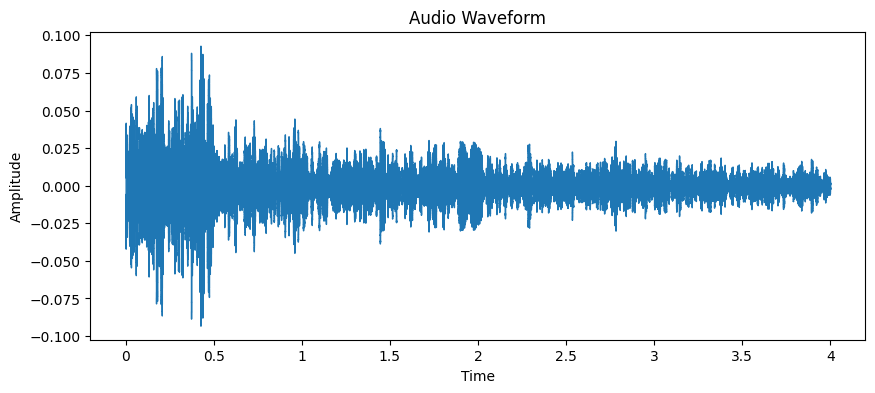

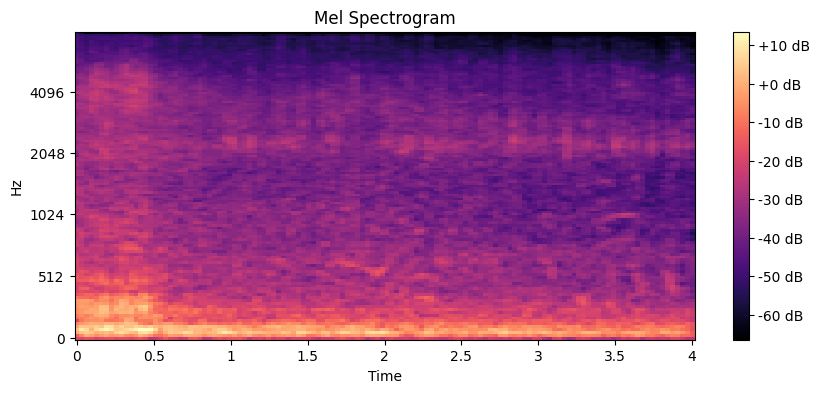

Class: CombinedAudio


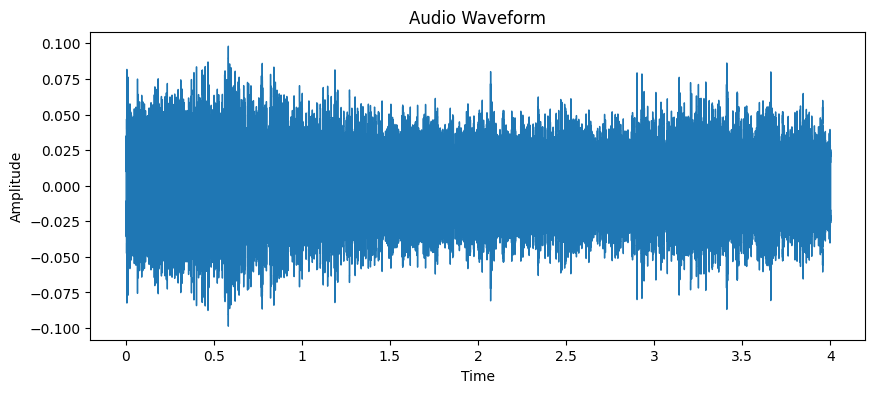

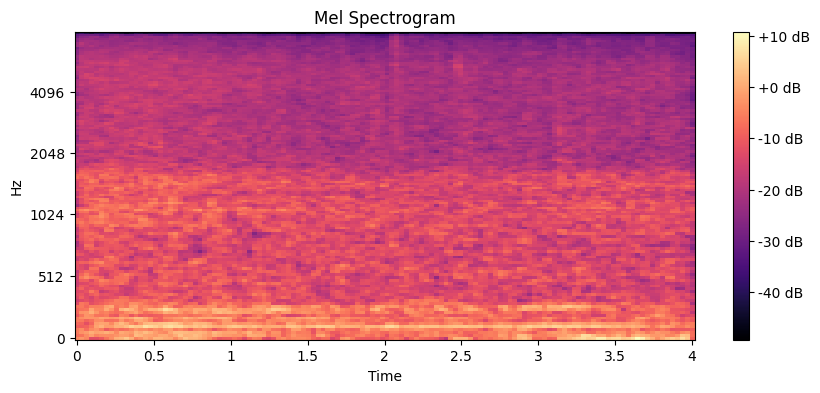

Class: CombinedAudio


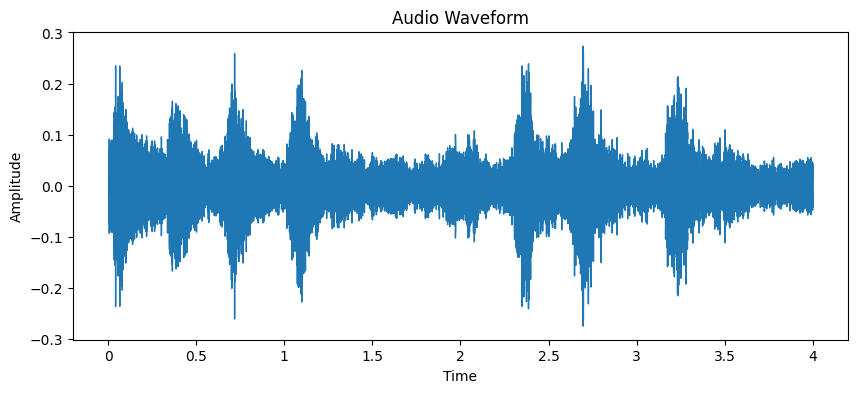

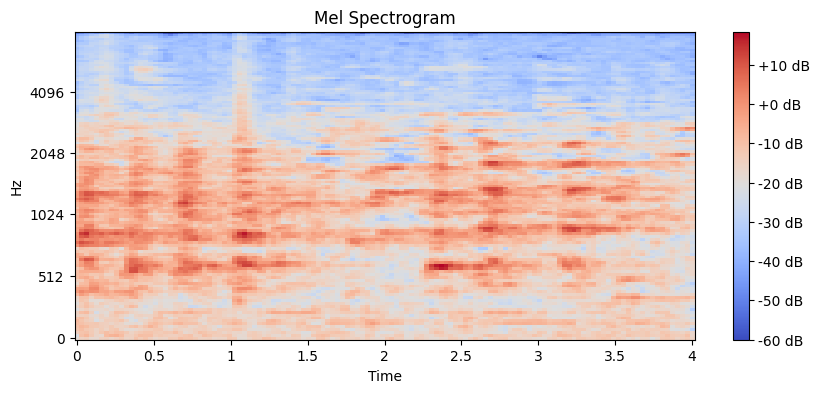

In [7]:
import random

for i in range(3):

    label = random.choice(os.listdir(DATASET_PATH))
    file = random.choice(os.listdir(os.path.join(DATASET_PATH, label)))

    sample = os.path.join(DATASET_PATH, label, file)

    print("Class:", label)

    plot_waveform(sample)
    plot_spectrogram(sample)

In [8]:
#creating labels
def auto_label(file_path):

    signal, sr = librosa.load(file_path, sr=16000)
    peak_energy = np.max(np.abs(signal))

    if peak_energy > 0.6:
        return "gunshot"
    else:
        return "background"

In [9]:
#feature extraction
def extract_embedding(file_path):

    waveform, sr = librosa.load(file_path, sr=16000)
    waveform = waveform.astype(np.float32)

    scores, embeddings, spectrogram = yamnet_model(waveform)
    embedding = tf.reduce_mean(embeddings, axis=0)

    return embedding.numpy()

In [10]:
X = []
y = []

for label in os.listdir(DATASET_PATH):

    label_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(label_path):
        continue

    for file in os.listdir(label_path):

        if file.endswith(".wav"):

            path = os.path.join(label_path, file)

            try:
                emb = extract_embedding(path)
                label = auto_label(path)

                X.append(emb)
                y.append(label)

            except:
                pass

X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)

I0000 00:00:1773027497.854657      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


Dataset Shape: (11731, 1024)


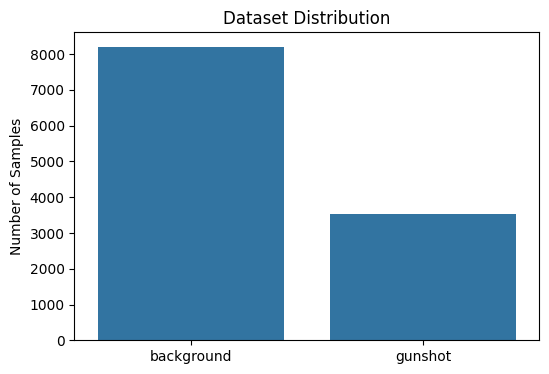

In [11]:
#dataset distribution
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(6,4))
sns.barplot(x=unique, y=counts)

plt.title("Dataset Distribution")
plt.ylabel("Number of Samples")

plt.show()

In [12]:
#encoding labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['background' 'gunshot']


In [13]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [14]:
#model building
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X.shape[1],)),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,682 (1.16 MB)

 Trainable params: 303,682 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(

    X_train,
    y_train,

    epochs=30,
    batch_size=32,

    validation_data=(X_test, y_test)
)

Epoch 1/30


I0000 00:00:1773027932.730291      74 service.cc:152] XLA service 0x7804e4009fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773027932.730330      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773027932.730353      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 73/294 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7660 - loss: 0.5152

I0000 00:00:1773027934.909310      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8091 - loss: 0.4454 - val_accuracy: 0.8628 - val_loss: 0.3190
Epoch 2/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8575 - loss: 0.3312 - val_accuracy: 0.8756 - val_loss: 0.3069
Epoch 3/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8709 - loss: 0.3067 - val_accuracy: 0.8764 - val_loss: 0.2962
Epoch 4/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8785 - loss: 0.2900 - val_accuracy: 0.8794 - val_loss: 0.2740
Epoch 5/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8882 - loss: 0.2672 - val_accuracy: 0.8811 - val_loss: 0.2785
Epoch 6/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8948 - loss: 0.2562 - val_accuracy: 0.8854 - val_loss: 0.2591
Epoch 7/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8984 - loss: 0.2444 - val_accuracy: 0.8922 - val_loss: 0.2517
Epoch 8/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9039 - loss: 0.2281 - val_accuracy: 0.8884 - val

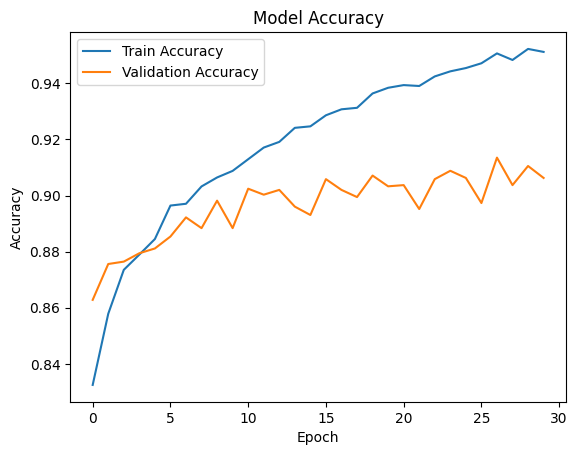

In [16]:
#training performance
plt.figure()

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

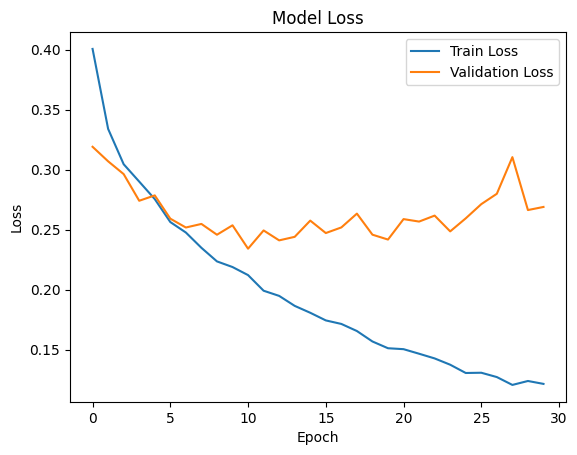

In [17]:
plt.figure()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [18]:
#model evaluation
pred = model.predict(X_test)

pred_labels = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_labels))

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      1632
           1       0.88      0.80      0.84       715

    accuracy                           0.91      2347
   macro avg       0.90      0.88      0.89      2347
weighted avg       0.91      0.91      0.91      2347



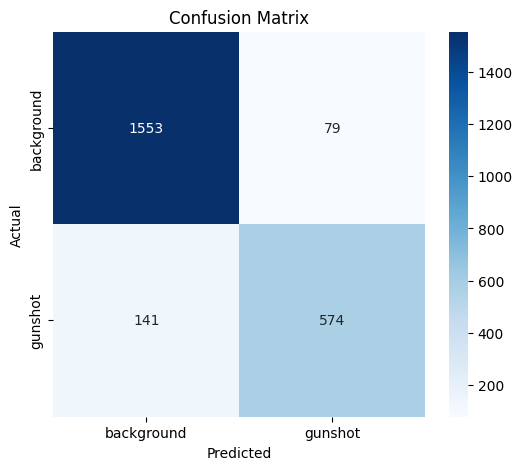

In [19]:
cm = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
#saving the model
model.save("gunshot_detection_model.h5")

joblib.dump(encoder, "label_encoder.pkl")

print("Model Saved Successfully")

Model Saved Successfully
